[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/k_brazos/ucb1_binomial_dist_experiment.ipynb)

# Estudio del bandido de k-brazos mediante el algoritmo UCB1 con distribución binomial

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo UCB1 con brazos cuya recompensa viene dada por una función de distribución binomial.

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/k_brazos/
%ls

## Constantes

In [3]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/ucb1_binomial_dist"

## Librerías

In [4]:
import sys
import random
import numpy as np

sys.path.append('./src')

from arms import ArmBinomial, Bandit
from experiment import run_experiment
from algorithms import UCB1
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

## Reproducibilidad

In [5]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertinente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas por brazo.

In [6]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBinomial.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBinomial (n=100, p=0.39), ArmBinomial (n=100, p=0.91), ArmBinomial (n=100, p=0.71), ArmBinomial (n=100, p=0.19), ArmBinomial (n=100, p=0.59), ArmBinomial (n=100, p=0.1), ArmBinomial (n=100, p=0.83), ArmBinomial (n=100, p=0.69), ArmBinomial (n=100, p=0.07), ArmBinomial (n=100, p=0.92)
Optimal arm: 10 with expected reward=0.92


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 10 con una recompensa media esperada de 0.92. Se van a comparar los resultados con distintos valores para la exploración:
 - exploration = 0
 - exploration = 1
 - exploration = 5
 - exploration = 10

In [7]:
##### Definir los algoritmos ucb1 con diferente epsilon
algorithms_ucb1 = [
    UCB1(k=K, exploration=0),
    UCB1(k=K, exploration=1),
    UCB1(k=K, exploration=5),
    UCB1(k=K, exploration=10)
]

# Ejecutar el experimento
rewards_ucb1, optimal_selections_ucb1, regret_accumulated_ucb1, arm_stats_ucb1 = run_experiment(bandit, algorithms_ucb1, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obtenidos mediante las correspondientes gráficas.

#### Recompensas promedio

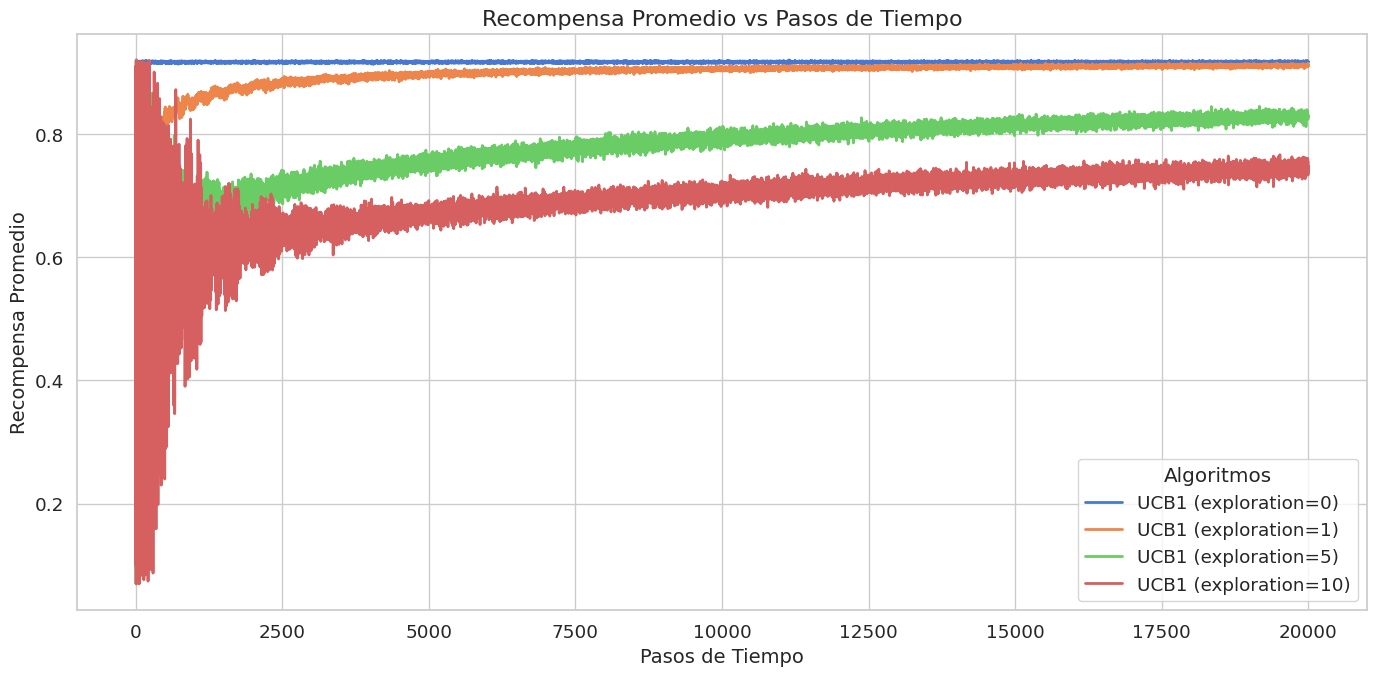

In [8]:
plot_average_rewards(STEPS, rewards_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Lo primero que se aprecia es más ruido que en las gráficas de recompensa estudiadas en otros notebooks, esto es debido a que en los primeros pasos, por cuestiones de probabilidad, es más fácil que aunque el algoritmo elija el brazo óptimo pueda no recibir la recompensa de éxito lo que desajusta temporalmente el algoritmo hasta que pasan suficientes pasos de tiempo para mitigar este efecto. Este ruido es visible para exploration=5, las variantes con menos componente exploratoria se estabilizan antes y convergen en una media cercana a la del brazo óptimo.

#### Selecciones óptimas

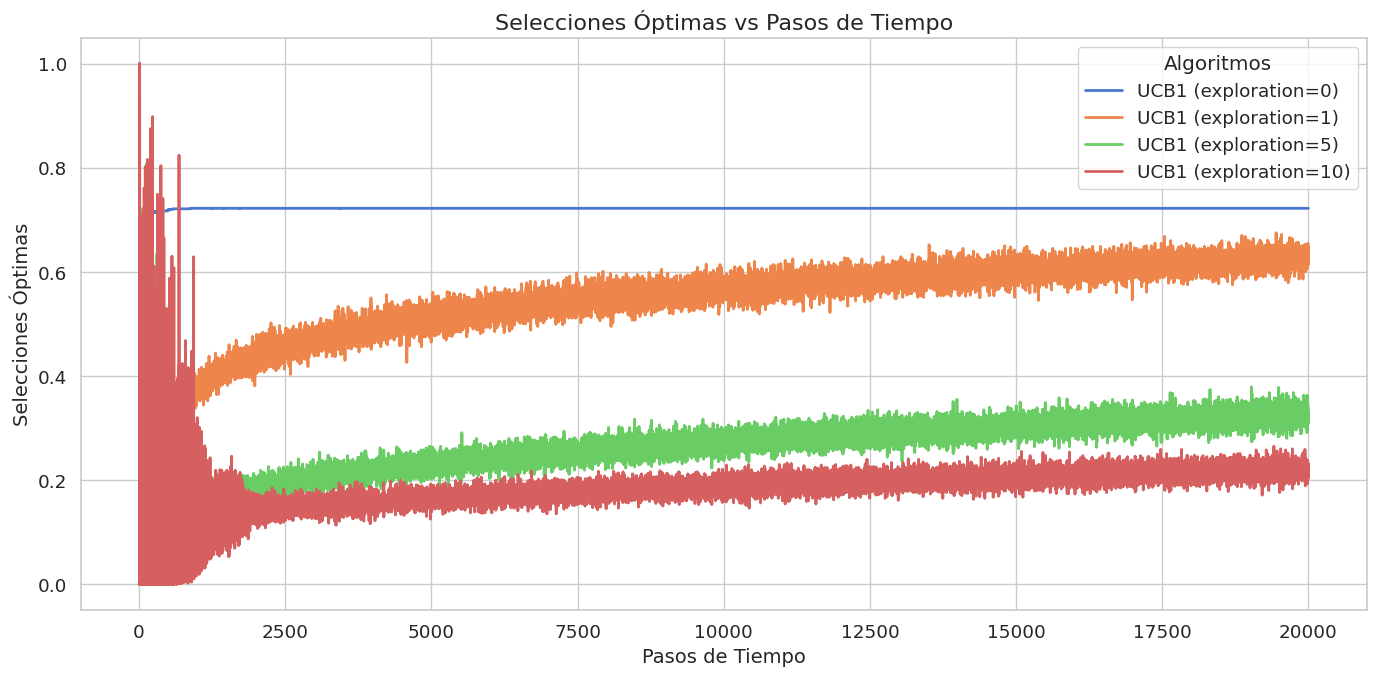

In [9]:
plot_optimal_selections(STEPS, optimal_selections_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

En cuanto al número de selecciones óptimas a lo largo del tiempo, el algoritmo no exploratorio se mantiene constante sobre el 75% y le sigue la versión con exploration=1, que en los pasos estudiados no la supera, pero podría hacerlo con más tiempo.

#### Arrepentimiento

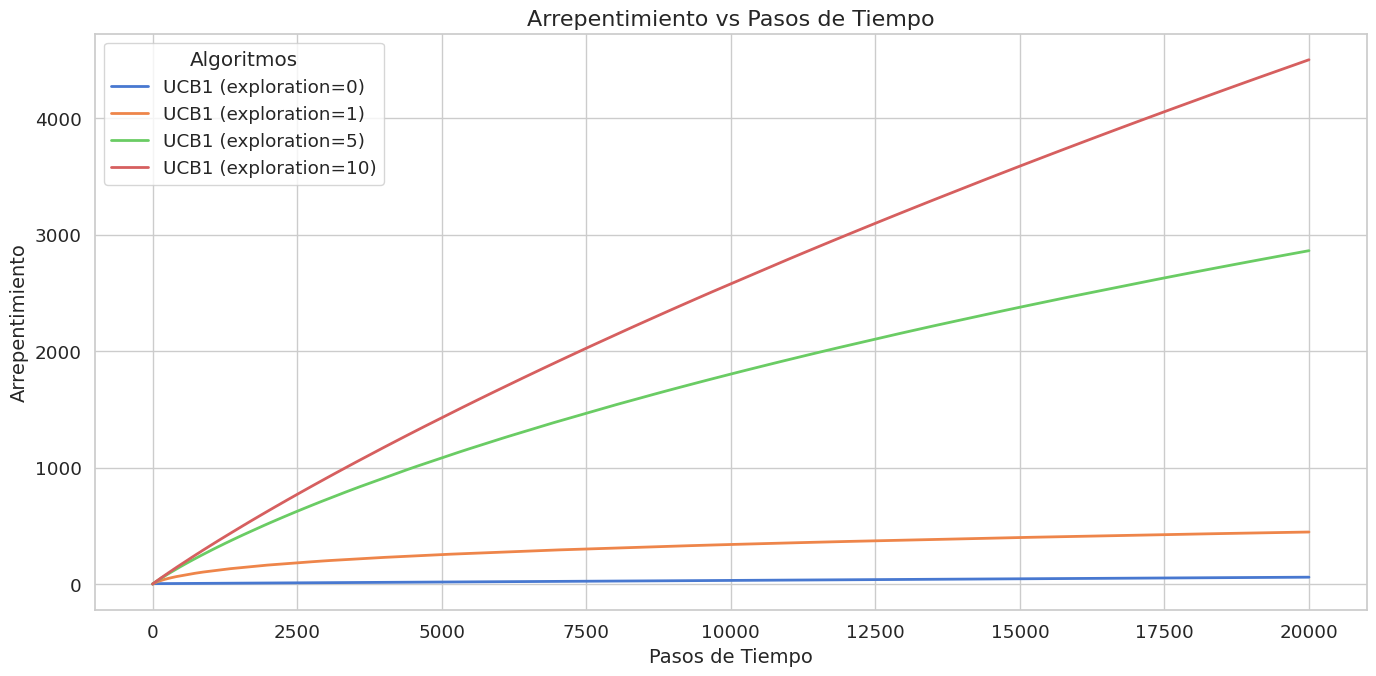

In [10]:
plot_regret(STEPS, regret_accumulated_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

El gráfico de arrepentimiento acumulado no aporta información nueva relevante. Se puede destacar que el algoritmo explotador en promedio elige el brazo óptimo u otros muy cercanos a este por su bajo arrepentimiento.

#### Estadísticas por brazo

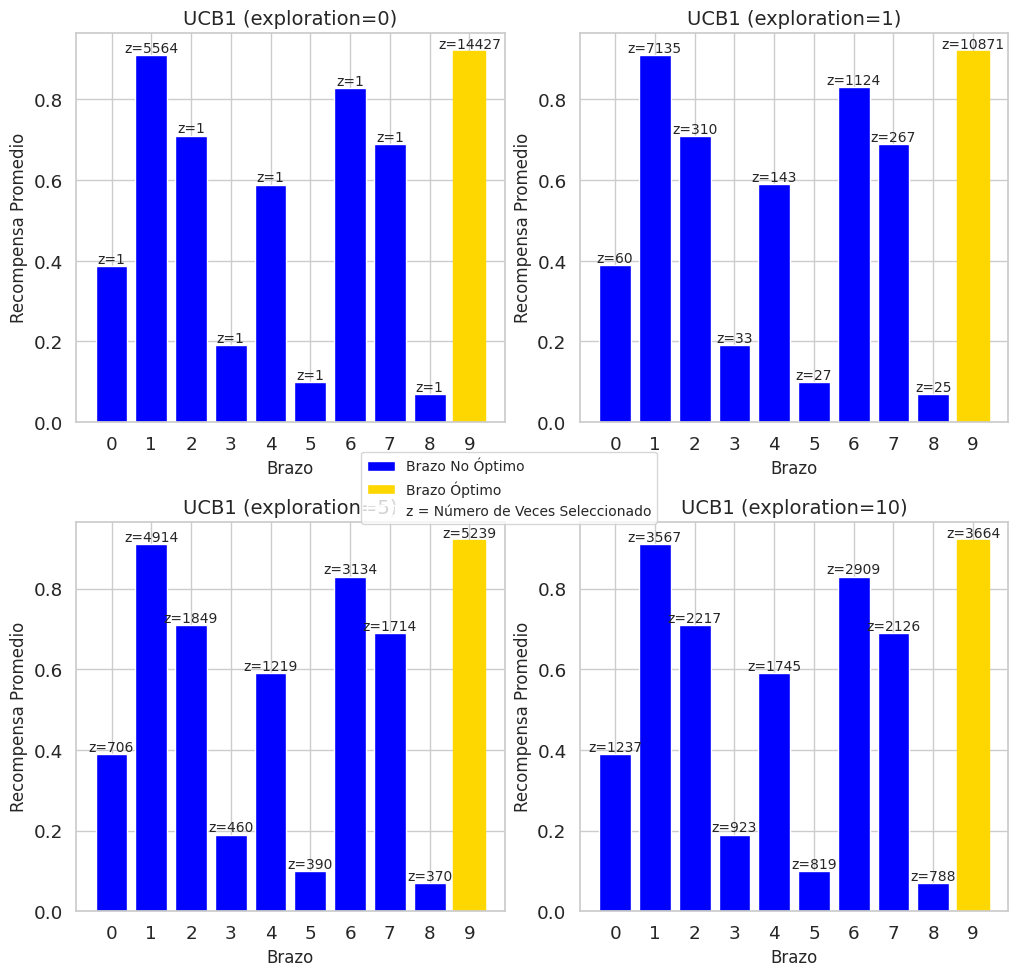

In [11]:
plot_arm_statistics(arm_stats_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Las estadísticas de exploration=0 confirma que en prácticamente todas las ejecuciones el algoritmo ha elegido uno de los dos mejores brazos.

## Conclusiones

La información más relevante de este ensayo es el ruido en los primeros pasos provocado por la fusión de una distribución basada en probabilidades con un algoritmo que promueve la elección de brazos menos explotados. Puede darse el caso donde tardará en rectificar la media de recompensa de brazos buenos, pero con bajas recompensas iniciales por su naturaleza estocástica.